In [70]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
import matplotlib.patches as mpatches
from find_best_K import find_best_K_F, generate_alpha_list, get_labels_at_K
from hierarchical_clustering_invariant import * 
from palmerpenguins import load_penguins

In [129]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *
import rpy2.robjects as ro
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import default_converter
from rpy2.robjects import numpy2ri, r
import warnings
import logging


warnings.filterwarnings("ignore", category=UserWarning)
logging.getLogger("rpy2.rinterface_lib.callbacks").setLevel(logging.ERROR)

In [2]:
penguins_raw = load_penguins()
penguins_raw

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009


In [3]:
penguins = penguins_raw[(penguins_raw["sex"] == "female") & (penguins_raw.notna().all(axis=1))& (penguins_raw["year"].between(2007,2008))]

In [122]:
labels = penguins["species"]
X = penguins[["flipper_length_mm","bill_length_mm"]].to_numpy()
np.random.seed(1) 
ind = np.random.choice(X.shape[0], 30, replace=False)
subset_mat = X[ind, :]
subset_labels = labels.iloc[ind]

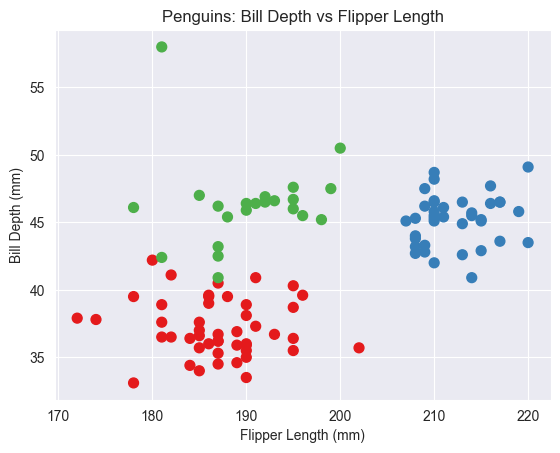

In [123]:
import matplotlib.pyplot as plt
import seaborn as sns

species_unique = penguins["species"].unique()
palette = sns.color_palette("Set1", len(species_unique))
color_map = dict(zip(species_unique, palette))

plt.scatter(
    penguins["flipper_length_mm"],
    penguins["bill_length_mm"],
    c=penguins["species"].map(color_map),
    s=50
)

plt.xlabel("Flipper Length (mm)")
plt.ylabel("Bill Depth (mm)")
plt.title("Penguins: Bill Depth vs Flipper Length")
plt.show()

## p-values comparison

In [124]:
def get_labels_from_model(model):
    # Extract the cluster nodes
    clusters = model.K_clusters  # last merge level = final clusters

    # Compute total number of samples
    n = max(max(c.points) for c in clusters) + 1

    # Initialize label array
    labels_est = np.empty(n, dtype=int)

    # Assign labels
    for k, c in enumerate(clusters, start=1):
        for idx in c.points:
            labels_est[idx] = k

    return labels_est

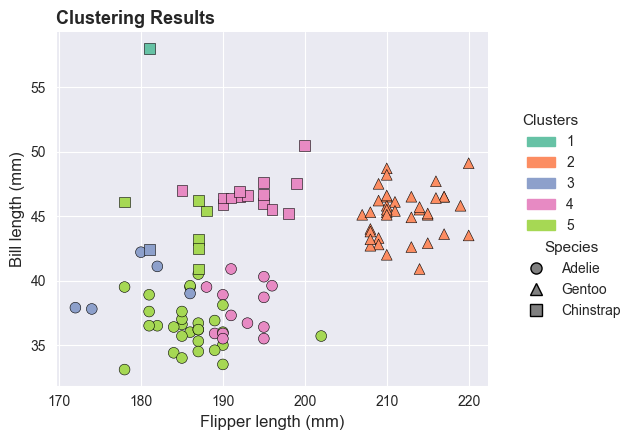

In [125]:
random.seed(48)
model = AgglomerativeClustering(X,n_clusters=5, tau=0.1, linkage="average")
model.fit()
labels_est = get_labels_from_model(model)
# --- Define color map for clusters ---
n_labels = len(set(labels_est))
palette = sns.color_palette("Set2", n_labels)
color_map = dict(zip(sorted(set(labels_est)), palette))

# --- Define marker map for species ---
species_unique = penguins["species"].unique()
markers = ["o", "^", "s", "D", "v"] 
marker_map = dict(zip(species_unique, markers))

penguins = penguins.reset_index(drop=True)

# --- Plot ---
plt.figure(figsize=(6.5, 4.5))
for species in species_unique:
    subset = penguins[penguins["species"] == species]
    plt.scatter(
        subset["flipper_length_mm"],
        subset["bill_length_mm"],
        c=[color_map[l] for l in labels_est[subset.index]],
        s=60,
        marker=marker_map[species],
        edgecolor="black",
        linewidth=0.4,
    )

plt.xlabel("Flipper length (mm)", fontsize=12)
plt.ylabel("Bill length (mm)", fontsize=12)
plt.title("Clustering Results", loc="left", fontsize=13, weight="bold")

cluster_patches = [
    mpatches.Patch(color=color_map[k], label=str(k)) for k in sorted(color_map)
]
cluster_legend = plt.legend(
    handles=cluster_patches,
    title="Clusters",
    title_fontsize=11,
    fontsize=10,
    loc="center left",
    bbox_to_anchor=(1.05, 0.6),
    frameon=False,
)

species_handles = [
    plt.Line2D(
        [0],
        [0],
        marker=marker_map[s],
        color="w",
        markerfacecolor="gray",
        markeredgecolor="black",
        markersize=8,
        linestyle="",
        label=s,
    )
    for s in species_unique
]
species_legend = plt.legend(
    handles=species_handles,
    title="Species",
    title_fontsize=11,
    fontsize=10,
    loc="center left",
    bbox_to_anchor=(1.05, 0.3),
    frameon=False,
)

plt.gca().add_artist(cluster_legend)

sns.despine()
plt.tight_layout()
plt.show()

In [147]:
pairs = combinations(np.arange(5), 2)
pair_list = []
pvals = []
for pair in pairs:
    print(pair)
    pair_list.append(pair)
    c1 = model.K_clusters[pair[0]]
    c2 = model.K_clusters[pair[1]]
    pval, _, _ = model.merge_inference_F_random_pair_grid(c1,c2, grid_width=120, ncoarse=30, ngrid=2000)
    pvals.append(pval)
    
rows = []
for pair_ind, pval in zip(pair_list, pvals):
    pair_plus_one = tuple(i + 1 for i in pair_ind)
    rows.append((pair_plus_one,pval))
df= pd.DataFrame(rows, columns=["Pair","pval"])

(np.int64(0), np.int64(1))
1e-05 120.0
(np.int64(0), np.int64(2))
1e-05 120.0
(np.int64(0), np.int64(3))
1e-05 104.94551916870404
(np.int64(0), np.int64(4))
1e-05 86.29422989943052
(np.int64(1), np.int64(2))
1e-05 120.0
(np.int64(1), np.int64(3))
1e-05 120.0
(np.int64(1), np.int64(4))
1e-05 120.0
(np.int64(2), np.int64(3))
1e-05 120.0
(np.int64(2), np.int64(4))
1e-05 76.68399925958843
(np.int64(3), np.int64(4))
1e-05 120.0


In [148]:
df

,Pair,pval
0,"(1, 2)",0.000073
1,"(1, 3)",0.173499
2,"(1, 4)",0.209348
3,"(1, 5)",0.053523
4,"(2, 3)",0.000000
5,"(2, 4)",0.000000
6,"(2, 5)",0.000000
7,"(3, 4)",0.545559
8,"(3, 5)",0.247402
9,"(4, 5)",0.570384


In [136]:
def compute_label(X, K=3, linkage = "average"):
    #ro.r('source("/home/judydw/RAC_invariant/r_functions.R")')
    ro.r('source("/Users/judydw/Documents/GitHub/SI_HierarchicalClustering/r_functions.R")')
    with localconverter(default_converter + numpy2ri.converter):
        ro.globalenv['X'] = ro.conversion.py2rpy(X)
    ro.globalenv['K_py'] = K
    ro.globalenv['link_py'] = linkage
    result = ro.r("get_labels(X, K_py, link_py)")
    return result

def compute_pval_gao(X, k1, k2, K=3, linkage = "average"):
    #ro.r('source("/home/judydw/RAC_invariant/r_functions.R")')
    ro.r('source("/Users/judydw/Documents/GitHub/SI_HierarchicalClustering/r_functions.R")')
    with localconverter(default_converter + numpy2ri.converter):
        ro.globalenv['X'] = ro.conversion.py2rpy(X)
    ro.globalenv['K_py'] = K
    ro.globalenv['k1_py'] = k2
    ro.globalenv['k2_py'] = k1
    ro.globalenv['link_py'] = linkage
    result = ro.r("get_pval(X, K_py, k1_py, k2_py, link_py)")
    return result

def get_pval_barber(X, K, k1, k2, linkage="average"):
    #ro.r('source("/home/judydw/RAC_invariant/r_functions.R")')
    ro.r('source("/Users/judydw/Documents/GitHub/SI_HierarchicalClustering/r_functions.R")')
    with localconverter(default_converter + numpy2ri.converter):
        ro.globalenv['X'] = ro.conversion.py2rpy(X)
    ro.globalenv['k1_py'] = k2
    ro.globalenv['k2_py'] = k1
    ro.globalenv['K_py'] = K
    ro.globalenv['link_py'] = linkage
    result = ro.r("get_barber_pval_pair(X, K_py, k1_py, k2_py, link_py)")
    return result

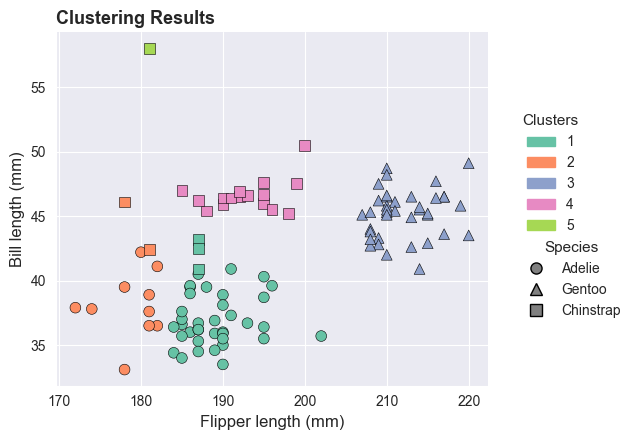

In [146]:
labels_est = np.array(compute_label(X, K=5, linkage = "average"))
# --- Define color map for clusters ---
n_labels = len(set(labels_est))
palette = sns.color_palette("Set2", n_labels)
color_map = dict(zip(sorted(set(labels_est)), palette))

# --- Define marker map for species ---
species_unique = penguins["species"].unique()
markers = ["o", "^", "s", "D", "v"] 
marker_map = dict(zip(species_unique, markers))

penguins = penguins.reset_index(drop=True)

# --- Plot ---
plt.figure(figsize=(6.5, 4.5))
for species in species_unique:
    subset = penguins[penguins["species"] == species]
    plt.scatter(
        subset["flipper_length_mm"],
        subset["bill_length_mm"],
        c=[color_map[l] for l in labels_est[subset.index]],
        s=60,
        marker=marker_map[species],
        edgecolor="black",
        linewidth=0.4,
    )

plt.xlabel("Flipper length (mm)", fontsize=12)
plt.ylabel("Bill length (mm)", fontsize=12)
plt.title("Clustering Results", loc="left", fontsize=13, weight="bold")

cluster_patches = [
    mpatches.Patch(color=color_map[k], label=str(k)) for k in sorted(color_map)
]
cluster_legend = plt.legend(
    handles=cluster_patches,
    title="Clusters",
    title_fontsize=11,
    fontsize=10,
    loc="center left",
    bbox_to_anchor=(1.05, 0.6),
    frameon=False,
)

species_handles = [
    plt.Line2D(
        [0],
        [0],
        marker=marker_map[s],
        color="w",
        markerfacecolor="gray",
        markeredgecolor="black",
        markersize=8,
        linestyle="",
        label=s,
    )
    for s in species_unique
]
species_legend = plt.legend(
    handles=species_handles,
    title="Species",
    title_fontsize=11,
    fontsize=10,
    loc="center left",
    bbox_to_anchor=(1.05, 0.3),
    frameon=False,
)

plt.gca().add_artist(cluster_legend)

sns.despine()
plt.tight_layout()
plt.show()

In [135]:
pairs = combinations(np.arange(5), 2)
pair_list = []
pvals_g = []
pvals_b = []
for pair in pairs:
    print(pair)
    pair_plus_one = tuple(i + 1 for i in pair)
    k1 = int(pair_plus_one[0])
    k2 = int(pair_plus_one[1])
    pair_list.append(pair_plus_one)
    pval_b = get_pval_barber(X,5, k1, k2)
    pvals_b.append(pval_b)
    pval_g = compute_pval_gao(X, k1, k2, 5)
    pvals_g.append(pval_g)
    
rows = []
for pair_ind, pval_g, pval_b in zip(pair_list, pvals_g, pvals_b):
    rows.append((pair_ind,pval_g, pval_b))
df= pd.DataFrame(rows, columns=["Pair","pval_Gao","pval_Barber"])
df

(np.int64(0), np.int64(1))
(np.int64(0), np.int64(2))
(np.int64(0), np.int64(3))
(np.int64(0), np.int64(4))
(np.int64(1), np.int64(2))
(np.int64(1), np.int64(3))
(np.int64(1), np.int64(4))
(np.int64(2), np.int64(3))
(np.int64(2), np.int64(4))
(np.int64(3), np.int64(4))


,Pair,pval_Gao,pval_Barber
0,"(1, 2)",[0.618817017068719],[0.10044851125156577]
1,"(1, 3)",[2.829470083103708e-13],[0.002152362526217584]
2,"(1, 4)",[0.735246983852718],[0.25213445285467806]
3,"(1, 5)",[0.24886913333015626],[0.04120823622065013]
4,"(2, 3)",[0.08837780125149178],[0.025836109307936766]
5,"(2, 4)",[0.32440630715160784],[0.12312331175934918]
6,"(2, 5)",[0.46447108250189123],[0.33215738289192176]
7,"(3, 4)",[6.618149112727882e-06],[0.0030398051749769726]
8,"(3, 5)",[0.05383152514852819],[5.9066482886743204e-08]
9,"(4, 5)",[0.34624216864668544],[0.12457505331242175]


## Choose K

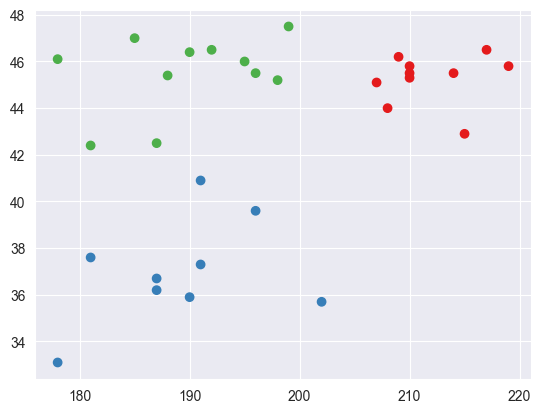

In [19]:
species_unique_sub = subset_labels.unique()
palette_sub = sns.color_palette("Set1", len(species_unique_sub))
color_map = dict(zip(species_unique_sub, palette_sub))
plt.scatter(subset_mat[:,0],subset_mat[:,1],c=subset_labels.map(color_map))

In [32]:
n = subset_mat.shape[0]
total_alpha = 0.05
#alpha_list = np.full(n - 1, total_alpha / (n - 1))
alpha_list = generate_alpha_list(n,total_alpha)
Khat, _, _, labels_est =find_best_K_F(subset_mat, 0.05, alpha_list,total_alpha)

1e-05 180.0
1e-05 180.0
1e-05 180.0
1e-05 180.0
1e-05 180.0
1e-05 136.61216955314922
1e-05 109.8445447301129
1e-05 145.79807813257932
1e-05 161.14053791786415
1e-05 76.64879762036936
1e-05 137.33823715825122
1e-05 69.61687211267432
1e-05 114.3913447004311
1e-05 35.58100352725789
1e-05 28.797356737530382
1e-05 66.76917229688114
1e-05 56.20007513500143
1e-05 153.37039327673585


In [33]:
Khat

2

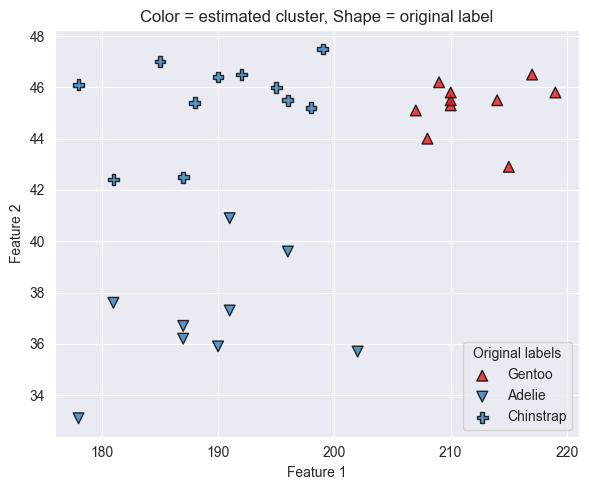

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# unique groups for original labels
species_unique_sub = subset_labels.unique()
shapes = ["^", "v", "P", "X"]  # enough shapes for up to 7 classes
shape_map = dict(zip(species_unique_sub, shapes))

# unique groups for new clustering
cluster_unique = np.unique(labels_est)
palette_sub = sns.color_palette("Set1", len(cluster_unique))
color_map = dict(zip(cluster_unique, palette_sub))

# plotting
plt.figure(figsize=(6,5))
for sp in species_unique_sub:
    idx = subset_labels == sp
    plt.scatter(
        subset_mat[idx, 0],
        subset_mat[idx, 1],
        c=[color_map[l] for l in labels_est[idx]],  # color by cluster
        marker=shape_map[sp],                      # shape by original label
        s=60,
        edgecolor="black",
        alpha=0.8,
        label=str(sp)
    )

plt.legend(title="Original labels")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Color = estimated cluster, Shape = original label")
plt.tight_layout()
plt.show()


1e-05 180.0
1e-05 180.0
1e-05 180.0
1e-05 176.2046478477779
1e-05 91.85746161223415
1e-05 100.9866312770418
1e-05 96.64701285135246
1e-05 180.0
1e-05 180.0
1e-05 112.53786288363469
1e-05 93.89309823887048
1e-05 180.0
1e-05 99.5938578186987
1e-05 71.86468316682826
1e-05 180.0
1e-05 180.0
1e-05 180.0
1e-05 180.0
1e-05 180.0
1e-05 180.0
1e-05 158.21304718997237
1e-05 128.40264352632775
1e-05 180.0
1e-05 108.07124097194077
1e-05 80.13346070749952
1e-05 180.0
1e-05 24.422167879470116
1e-05 82.29698594093337
1e-05 59.81499751607197
1e-05 82.08292332886433
1e-05 54.45377250179565
1e-05 55.51193312031168
1e-05 180.0
1e-05 171.34132030365106
1e-05 180.0
1e-05 180.0
1e-05 180.0
1e-05 180.0
1e-05 94.78330324329897
1e-05 120.67387472802612
1e-05 180.0
1e-05 117.61282945084973
1e-05 164.64321701896932
1e-05 180.0
1e-05 74.87523206107477
1e-05 180.0
1e-05 100.97724860694578
1e-05 92.95109931425176
1e-05 180.0
1e-05 70.18868066761186
1e-05 149.42257836657996
1e-05 180.0
1e-05 180.0
1e-05 180.0
1e-05 

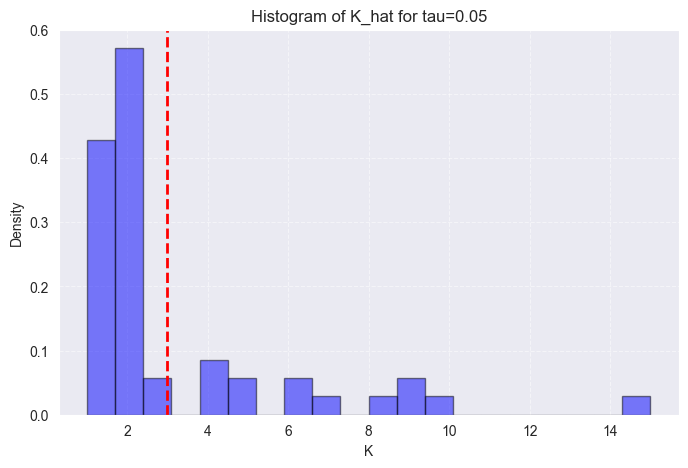

<bound method Counter.most_common of Counter({2: 20, 1: 15, 4: 3, 3: 2, 5: 2, 6: 2, 9: 2, 7: 1, 15: 1, 10: 1, 8: 1})>

In [33]:
n=30
true_K=3
total_alpha = 0.05
num_trials = 50
Ks = []
alpha_list = np.full(n - 1, total_alpha / (n - 1))
for _ in range(num_trials):
    K,_,_ = find_best_K_F(subset_mat, tau=0.1, alpha_list=alpha_list)
    Ks.append(K)
plt.figure(figsize=(8, 5))
plt.hist(Ks, bins=20, density=True, alpha=0.5, color="blue", edgecolor="black",
             label="K hat")
plt.axvline(x=true_K, color='red', linestyle='--', linewidth=2, label=f"True K = {true_K}")
plt.xlabel("K")
plt.ylabel("Density")
plt.title("Histogram of K_hat for tau=0.05")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()
from collections import Counter
counter = Counter(Ks)
counter.most_common

In [16]:
X.dtypes

bill_depth_mm        float64
flipper_length_mm    float64
dtype: object

In [1]:
from scipy.cluster.hierarchy import linkage, fcluster
def wcss_from_labels(X, labels):
    """Compute WCSS given cluster labels."""
    wcss = 0
    for k in np.unique(labels):
        cluster_points = X[labels == k]
        center = cluster_points.mean(axis=0)
        wcss += ((cluster_points - center) ** 2).sum()
    return wcss

def compute_wcss_hclust(X, n_clusters, method="complete"):
    Z = linkage(X, method=method)
    labels = fcluster(Z, n_clusters, criterion="maxclust")
    return wcss_from_labels(X, labels)

def gap_statistic(X, K_max=30, B=50, method="complete", true_labels = None, random_state=None):
    rng = np.random.RandomState(random_state)

    mins = X.min(axis=0)
    maxs = X.max(axis=0)

    log_wcss = np.zeros(K_max)
    gap = np.zeros(K_max)
    sk = np.zeros(K_max)

    for k in range(1, K_max + 1):
        wk = compute_wcss_hclust(X, k, method=method)
        log_wcss[k - 1] = np.log(wk)
        wk_refs = np.zeros(B)
        for b in range(B):
            X_ref = rng.uniform(mins, maxs, size=X.shape)
            wk_refs[b] = compute_wcss_hclust(X_ref, k, method=method)
        log_wk_refs = np.log(wk_refs)

        gap[k - 1] = np.mean(log_wk_refs) - log_wcss[k - 1]
        sk[k - 1] = np.std(log_wk_refs) * np.sqrt(1 + 1 / B)

    for k in range(1, K_max):
        if gap[k - 1] >= gap[k] - sk[k]:
            best_K = k
            break
    else:
        best_K = K_max

    recover = None
    if true_labels is not None:
        Z = linkage(X, method=method)
        if best_K >= 3:
            labels_est = fcluster(Z, best_K, criterion="maxclust")
        else:
            labels_est = fcluster(Z, 3, criterion="maxclust")

        recover = True
        for lab in np.unique(labels_est):
            if len(np.unique(true_labels[labels_est == lab])) > 1:
                recover = False
                break

    return best_K, gap, sk, recover

In [2]:
gap_statistic(X, K_max=107, B=500, method="complete")

NameError: name 'X' is not defined